# Sprint 6 – Opdracht 1: Voorspellingen vergelijken

## Setup

In [7]:
import os
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


def connect_to_database(db_filename="database.sqlite"):
    """
    Zoekt naar het databasebestand in de huidige map en bovenliggende mappen
    en maakt een read-only SQLite-verbinding.

    Args:
        db_filename (str): Naam van het SQLite-bestand. Default: 'database.sqlite'.

    Returns:
        sqlite3.Connection: Een actieve read-only databaseverbinding.

    Raises:
        FileNotFoundError: Als het bestand niet gevonden kan worden.
    """
    current_dir = Path.cwd()
    possible_paths = [
        current_dir / db_filename,
        current_dir / "notebook" / db_filename,
        current_dir.parent / "notebook" / db_filename,
        current_dir.parent / db_filename,
    ]

    target_path = next(
        (p for p in possible_paths if p.is_file() and p.stat().st_size > 0),
        None
    )

    if not target_path:
        checked = "\n".join(f"  - {p}" for p in possible_paths)
        raise FileNotFoundError(f"Kon '{db_filename}' niet vinden.\nGecontroleerde locaties:\n{checked}")

    print(f"Database gevonden: {target_path}")
    connection = sqlite3.connect(f"file:{target_path}?mode=ro", uri=True)
    print("Verbonden met de database.")
    return connection


conn = connect_to_database()

Database gevonden: c:\Users\sasha\Documents\GitHub\Datalab_semester2_Groep1\notebook\database.sqlite
Verbonden met de database.


## BookmakerAnalyzer

In [8]:
class BookmakerAnalyzer:
    """
    Haalt bookmaker-odds op, rekent ze om naar kansen en bepaalt
    het voorspelde en werkelijke resultaat per wedstrijd.

    Attributes:
        conn (sqlite3.Connection): Actieve databaseverbinding.
    """

    def __init__(self, connection):
        """
        Initialiseert de analyzer met een databaseverbinding.

        Args:
            connection (sqlite3.Connection): Actieve databaseverbinding.
        """
        self.conn = connection

    def load_match_odds(self, bookmaker_prefix="GB"):
        """
        Haalt wedstrijdgegevens en odds op voor een specifieke bookmaker.

        Args:
            bookmaker_prefix (str): Kolom-prefix van de bookmaker in de database
                                   (bijv. 'GB' voor GBA). Default: 'GB'.

        Returns:
            pd.DataFrame: Wedstrijd-data met odds_home, odds_draw en odds_away.
        """
        query = f"""
            SELECT
                match_api_id,
                home_team_goal,
                away_team_goal,
                home_team_api_id,
                away_team_api_id,
                {bookmaker_prefix}H AS odds_home,
                {bookmaker_prefix}D AS odds_draw,
                {bookmaker_prefix}A AS odds_away
            FROM Match
            WHERE {bookmaker_prefix}H IS NOT NULL
              AND {bookmaker_prefix}D IS NOT NULL
              AND {bookmaker_prefix}A IS NOT NULL;
        """
        return pd.read_sql_query(query, self.conn)

    def convert_odds_to_probabilities(self, df):
        """
        Rekent decimale odds om naar impliciete kansen (1 / odds) en
        berekent de totale marge (overround) per wedstrijd.

        Args:
            df (pd.DataFrame): DataFrame met kolommen odds_home, odds_draw, odds_away.

        Returns:
            pd.DataFrame: Uitgebreid met prob_home, prob_draw, prob_away
                          en total_probability.
        """
        df = df.copy()
        for outcome in ("home", "draw", "away"):
            df[f"prob_{outcome}"] = 1 / df[f"odds_{outcome}"]
        df["total_probability"] = df[["prob_home", "prob_draw", "prob_away"]].sum(axis=1)
        return df

    def normalize_probabilities(self, df):
        """
        Normaliseert de kansen zodat ze per wedstrijd optellen tot 1.0,
        waarmee de winstmarge van de bookmaker wordt verwijderd.

        Args:
            df (pd.DataFrame): DataFrame met prob_home, prob_draw, prob_away
                               en total_probability.

        Returns:
            pd.DataFrame: Uitgebreid met prob_home_norm, prob_draw_norm,
                          prob_away_norm.
        """
        df = df.copy()
        for outcome in ("home", "draw", "away"):
            df[f"prob_{outcome}_norm"] = df[f"prob_{outcome}"] / df["total_probability"]
        return df

    def get_bookmaker_prediction(self, row):
        """
        Bepaalt de bookmaker-voorspelling op basis van de genormaliseerde
        kansen: de uitkomst met de hoogste kans.

        Args:
            row (pd.Series): Rij met prob_home_norm, prob_draw_norm, prob_away_norm.

        Returns:
            str: 'win', 'draw' of 'defeat'.
        """
        probs = {
            "win":    row["prob_home_norm"],
            "draw":   row["prob_draw_norm"],
            "defeat": row["prob_away_norm"],
        }
        return max(probs, key=probs.get)

    def get_actual_result(self, row):
        """
        Bepaalt het werkelijke resultaat op basis van de doelpunten.

        Args:
            row (pd.Series): Rij met home_team_goal en away_team_goal.

        Returns:
            str: 'win' (thuis wint), 'defeat' (uit wint) of 'draw'.
        """
        if row["home_team_goal"] > row["away_team_goal"]:
            return "win"
        elif row["home_team_goal"] < row["away_team_goal"]:
            return "defeat"
        return "draw"

## 1.1 Odds omrekenen naar kansen – wat valt er op?

In [9]:
analyzer = BookmakerAnalyzer(conn)

df = analyzer.load_match_odds(bookmaker_prefix="GB")
df = analyzer.convert_odds_to_probabilities(df)

print(f"Aantal wedstrijden: {len(df):,}")
df[["odds_home", "odds_draw", "odds_away",
    "prob_home", "prob_draw", "prob_away",
    "total_probability"]].head()

Aantal wedstrijden: 14,162


,odds_home,odds_draw,odds_away,prob_home,prob_draw,prob_away,total_probability
0,1.78,3.25,4.00,0.561798,0.307692,0.250000,1.119490
1,1.85,3.25,3.75,0.540541,0.307692,0.266667,1.114900
2,2.50,3.20,2.50,0.400000,0.312500,0.400000,1.112500
3,1.50,3.75,5.50,0.666667,0.266667,0.181818,1.115152
4,4.50,3.50,1.65,0.222222,0.285714,0.606061,1.113997


Wat direct opvalt is dat de opgetelde kansen per wedstrijd uitkomen op ongeveer **111–112%** in plaats van 100%. Dit verschil is de **winstmarge** van de bookmaker. De kansen zijn kunstmatig opgeblazen zodat de bookmaker altijd winst maakt, ongeacht de uitkomst. We moeten de kansen daarom eerst normaliseren naar 100% voordat we ze kunnen vergelijken.

## 1.2 Voorspeld resultaat van de bookmaker bepalen

In [10]:
df = analyzer.normalize_probabilities(df)
df["bookmaker_prediction"] = df.apply(analyzer.get_bookmaker_prediction, axis=1)

df[["odds_home", "odds_draw", "odds_away",
    "prob_home_norm", "prob_draw_norm", "prob_away_norm",
    "bookmaker_prediction"]].head()

,odds_home,odds_draw,odds_away,prob_home_norm,prob_draw_norm,prob_away_norm,bookmaker_prediction
0,1.78,3.25,4.00,0.501834,0.274850,0.223316,win
1,1.85,3.25,3.75,0.484833,0.275982,0.239184,win
2,2.50,3.20,2.50,0.359551,0.280899,0.359551,win
3,1.50,3.75,5.50,0.597826,0.239130,0.163043,win
4,4.50,3.50,1.65,0.199482,0.256477,0.544041,defeat


Na het normaliseren tellen de kansen per wedstrijd op tot precies 100%. De uitkomst met de hoogste kans wordt de voorspelling van de bookmaker.

## 1.3 Vergelijking met werkelijke resultaten

De bookmaker voorspelde de uitslag in 53.3% van de gevallen correct.
                 precision    recall  f1-score   support

  Winst (thuis)       0.54      0.87      0.67      6568
     Gelijkspel       0.48      0.00      0.01      3619
Verlies (thuis)       0.50      0.46      0.48      3975

       accuracy                           0.53     14162
      macro avg       0.51      0.44      0.39     14162
   weighted avg       0.52      0.53      0.45     14162



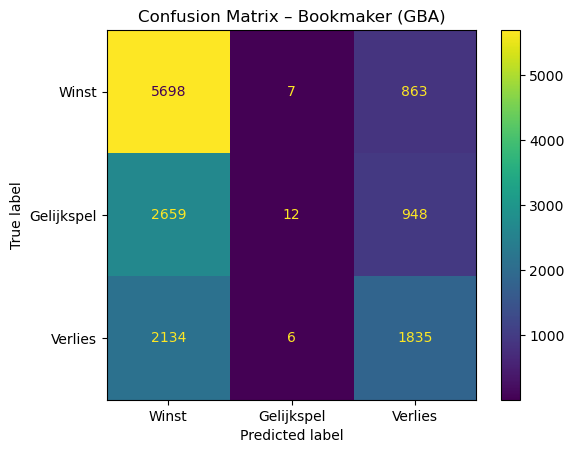

In [ ]:
df["actual_result"] = df.apply(analyzer.get_actual_result, axis=1)

bm_accuracy = (df["bookmaker_prediction"] == df["actual_result"]).mean()
print(f"De bookmaker voorspelde de uitslag in {bm_accuracy:.1%} van de gevallen correct.")

labels = ["win", "draw", "defeat"]
label_namen = ["Winst (thuis)", "Gelijkspel", "Verlies (thuis)"]

print(classification_report(
    df["actual_result"], df["bookmaker_prediction"],
    labels=labels, target_names=label_namen
))

ConfusionMatrixDisplay.from_predictions(
    df["actual_result"], df["bookmaker_prediction"],
    labels=labels, display_labels=["Winst", "Gelijkspel", "Verlies"]
)
plt.title("Confusion Matrix – Bookmaker (GBA)")
plt.savefig("confusion_matrix_bookmaker.png", dpi=150, bbox_inches="tight")
plt.show()

**Uitleg voor de Technisch Directeur:**

Bookmaker GBA voorspelt over de hele database {bm_accuracy:.1%} van de uitslagen
correct — dit is alleen op basis van accuracy een minder sterk beeld dan wat
de precision/recall per uitkomst laten zien.

- Bij **winst** presteert de bookmaker sterk: hoge precision én recall, wat
  betekent dat de bookmaker winstkansen betrouwbaar inschat.
- Bij **gelijkspel** presteert de bookmaker juist zwak: gelijke spelen krijgen
  bij bookmakers vrijwel nooit de hoogste kans, omdat een gelijkspel
  statistisch de minst voorkomende uitkomst is. Dit is exact hetzelfde
  probleem als bij ons eigen model, dat gelijkspelen ook slecht voorspelt
  (precision en recall van 0.00 voor deze klasse).
- Dit maakt de vergelijking met ons model eerlijker dan alleen op accuracy:
  beide modellen — de bookmaker over duizenden wedstrijden, en ons model over
  acht wedstrijden van Barcelona — hebben moeite met dezelfde uitkomst
  (gelijkspel), wat erop wijst dat dit een structureel lastig te voorspellen
  scenario is, niet een zwakte die uniek is aan ons model.

## Wat is er veranderd en waarom

**Leerdoel:** 8 Modelleren — criterium "Eigen model met bookmakers vergelijken"

**Feedback vorige beoordeling:** "Alleen accuracy wordt gebruikt en de toelichting voor de TD is summier."

| Waar | Oorspronkelijk | Aangepast | Waarom |
|---|---|---|---|
| 1.3 | Alleen `bm_accuracy` (één getal) | `classification_report` toegevoegd (precision, recall, f1-score per klasse) | Eén totaalpercentage verbergt dat de bookmaker sterk verschilt per uitkomst (winst vs. gelijkspel) |
| 1.3 | Geen visualisatie | `ConfusionMatrixDisplay` voor de bookmaker toegevoegd | Maakt visueel zichtbaar waar de bookmaker fout zit, net als de bestaande confusion matrix voor het eigen model, zodat de twee matrices naast elkaar gelegd kunnen worden |
| 1.3 | 3 zinnen, geen cijfermatige onderbouwing | Uitleg uitgebreid met concrete precision/recall-verschillen en een expliciete link naar de zwakte van het eigen model | De toelichting voor de Technisch Directeur was summier; de TD moet nu ook zonder de tabel te lezen begrijpen waarom accuracy alleen misleidend is |

**Niet veranderd:** de basisopzet (`BookmakerAnalyzer`, de query, de normalisatie) blijft ongewijzigd, omdat deze al volledig scoorde op de andere criteria (zelfgedefinieerde functies, DRY).